<a href="https://colab.research.google.com/github/clszvd/analytics_para_dados_industriais/blob/main/Analytics_para_dados_industriais.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Preparando o ambiente

1. Instalando os pacotes
2. Realizando os imports
3. Definindo as configurações (Variáveis de ambiente ou Secrets)
4. Baixando os arquivos de suporte.

In [8]:
!pip install uv

## Instalando os pacotes

In [9]:
!uv pip install python-dotenv ipykernel requests matplotlib pandas seaborn \
    tabulate numpy paho-mqtt plotly pymodbus scikit-learn scipy -q

## Importando os pacotes

In [10]:
# =======================
# Bibliotecas da standard library (Python)
# =======================

# Sistema operacional: criação de diretórios, configuração e leitura de variáveis de ambiente
import os

# Informações e manipulação da execução do interpretador Python
import sys

# Expressões regulares
import re

# Manipulação de datas e horários
import datetime

# Execução de funções assíncronas
import asyncio

# Conexões seguras e cliente HTTP assíncrono
import ssl
import httpx

# Manipulação de arquivos e diretórios de forma independente do sistema operacional
from pathlib import Path

# Manipulação de CSV, Excel, etc.
import pandas as pd

# Leitura de variáveis de ambiente a partir de arquivos `.env`
from dotenv import load_dotenv

# Requisições HTTP (síncronas)
import requests

# Exibição de gráficos e imagens
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# =======================
# Outros
# =======================

# Ignora avisos durante a execução
from IPython import get_ipython

import warnings
warnings.filterwarnings('ignore')

In [11]:
# Verifica onde o notebook está rodando
RUNNING_IN_COLAB = 'google.colab' in str(get_ipython())
try:
  from google.colab import userdata
except:
  pass

OUTPUT_DOCUMENTS_DIR:str = './documentos/' if not RUNNING_IN_COLAB else '/content/documentos/'

# Aula 1 - Fundamentos

## Análise de temperatura

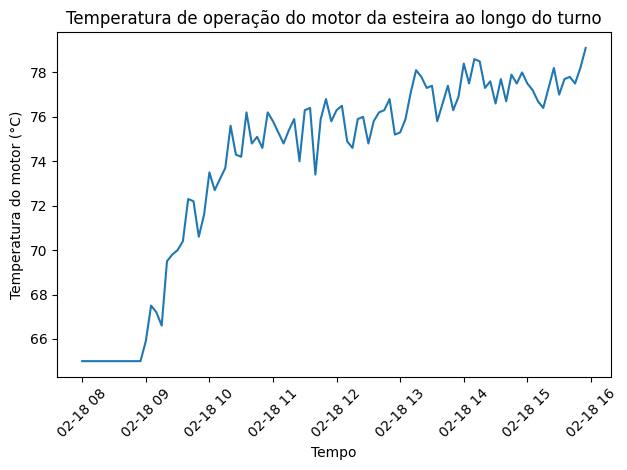

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# leitura de dados de temperatura do motor
url = "https://raw.githubusercontent.com/clszvd//analytics_para_dados_industriais/main/dados_motor_esteira.csv"
dados = pd.read_csv(url)
# tratar timestamp como datetime (recomendado)
dados["timestamp"] = pd.to_datetime(dados["timestamp"])
# visualização
plt.plot(dados["timestamp"], dados["temperatura_motor"])
plt.title("Temperatura de operação do motor da esteira ao longo do turno")
plt.xlabel("Tempo")
plt.ylabel("Temperatura do motor (°C)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Aula 2 - Controle de Vibração

## Cálculo do RMS

In [13]:
import numpy as np

# frequência de amostragem
fs = 1000

# vetor do tempo
tempo = np.arange(0, 1, 1/fs)

# sinal com componente senoidal + ruído
sinal = np.sin(2*np.pi*50*tempo) + 0.2*np.random.randn(len(tempo))

# cálculo do valor RMS
rms = np.sqrt(np.mean(sinal**2))

print("Valor RMS:", rms)

Valor RMS: 0.7393629228264438


## Gráfico de Vibração Simulado

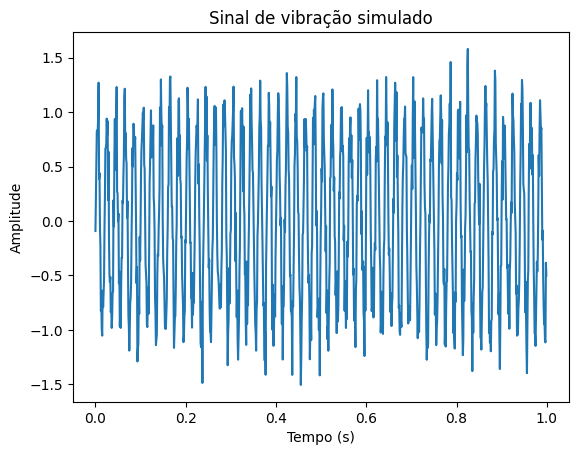

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# plotagem
plt.plot(tempo, sinal)
plt.title("Sinal de vibração simulado")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.show()


## Fast Fourier Transformation

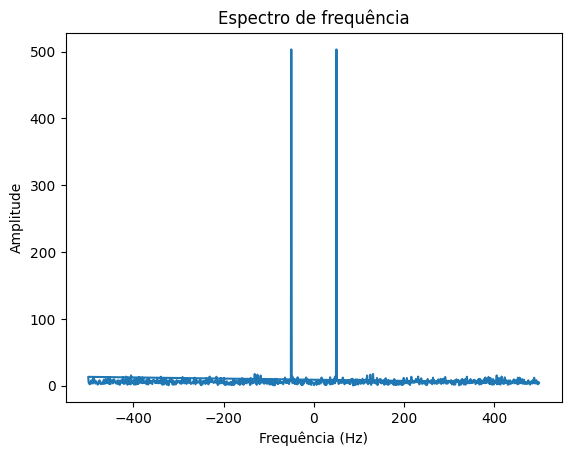

In [15]:
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt

fft_vals = fft(sinal)
freq = fftfreq(len(sinal), 1/fs)

plt.plot(freq, np.abs(fft_vals))
plt.title("Espectro de frequência")
plt.xlabel("Frequência (Hz)")
plt.ylabel("Amplitude")
plt.show()

# Cálculo de Atributos Estatísticos

In [16]:
from scipy.stats import kurtosis
# cálculo dos atributos

# média
media = np.mean(sinal)
# desvio padrão
desvio_padrao = np.std(sinal)
# valor máximo absoluto (Peak)
valor_maximo = np.max(np.abs(sinal))
# RMS (Root Mean Square)
rms = np.sqrt(np.mean(sinal**2))
# fator de crista (Crest Factor)
fator_crista = valor_maximo / rms
# curtose (Kurtosis)
curtose = kurtosis(sinal, fisher=False)
# exibição dos resultados
print("Atributos extraídos do sinal de vibração:")
print(f"Média: {media:.4f}")
print(f"Desvio padrão: {desvio_padrao:.4f}")
print(f"Valor máximo (Peak): {valor_maximo:.4f}")
print(f"RMS: {rms:.4f}")
print(f"Fator de crista: {fator_crista:.4f}")
print(f"Curtose: {curtose:.4f}")

Atributos extraídos do sinal de vibração:
Média: 0.0009
Desvio padrão: 0.7394
Valor máximo (Peak): 1.5808
RMS: 0.7394
Fator de crista: 2.1381
Curtose: 1.7300


## Cálculo de Atributos por Janelamento

In [17]:
janela = 100
atributos = []

for i in range(0, len(sinal)-janela, janela):

    trecho = sinal[i:i+janela]

    rms = np.sqrt(np.mean(trecho**2))
    peak = np.max(np.abs(trecho))
    crest = peak / rms
    kurt = kurtosis(trecho, fisher=False)

    atributos.append([rms, peak, crest, kurt])

atributos = np.array(atributos)

print("Shape da matriz de atributos:", atributos.shape)


Shape da matriz de atributos: (9, 4)


In [18]:
import pandas as pd
df_atributos = pd.DataFrame(atributos, columns=["RMS", "Peak", "Crest", "Kurtosis"])
df_atributos

,RMS,Peak,Crest,Kurtosis
0,0.699736,1.290787,1.844676,1.725602
1,0.724194,1.326966,1.832336,1.718391
2,0.734971,1.488167,2.024796,1.709110
3,0.766040,1.412873,1.844384,1.687013
4,0.763548,1.506279,1.972737,1.818050
5,0.702559,1.240335,1.765454,1.696433
6,0.726939,1.322537,1.819321,1.591049
7,0.764251,1.460763,1.911366,1.671109
8,0.785202,1.580808,2.013250,1.804372


## Simulação de Modelo Preditivo

In [19]:
# Gerando base sintética com MAIS OVERLAP para acurácia ~85-92%

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
n_normal = 200
n_falha = 100

# Normal: RMS baixo-médio, kurtosis ~2.8-3.5, crest 1.1-2.0 (overlap forte)
rms_normal = np.random.normal(0.045, 0.015, n_normal)  # Média maior
kurt_normal = np.random.normal(3.0, 0.6, n_normal)
crest_normal = np.random.normal(1.6, 0.4, n_normal)

# Falha: RMS médio, kurtosis 3.5-6.5, crest 2.5-5.5 (overlap)
rms_falha = np.random.normal(0.18, 0.08, n_falha)      # Média menor, std alta
kurt_falha = np.random.normal(4.8, 1.2, n_falha)
crest_falha = np.random.normal(3.8, 1.2, n_falha)

# Ruído adicional e outliers aleatórios
noise_scale = 0.03
noise_rms = np.random.normal(0, noise_scale, n_normal + n_falha)
noise_kurt = np.random.normal(0, 0.4, n_normal + n_falha)
noise_crest = np.random.normal(0, 0.3, n_normal + n_falha)

X_normal = np.column_stack([
    np.clip(rms_normal + noise_rms[:n_normal], 0.01, None),
    np.clip(kurt_normal + noise_kurt[:n_normal], 1.5, None),
    np.clip(crest_normal + noise_crest[:n_normal], 1.0, None)
])
X_falha = np.column_stack([
    np.clip(rms_falha + noise_rms[n_normal:], 0.01, None),
    np.clip(kurt_falha + noise_kurt[n_normal:], 2.5, None),
    np.clip(crest_falha + noise_crest[n_normal:], 1.5, None)
])
X = np.vstack([X_normal, X_falha])

# Injetando 10% de mislabels para realismo (ruído de rótulo)
y_base = np.array([0] * n_normal + [1] * n_falha)
mislabel_indices = np.random.choice(len(y_base), size=int(0.1 * len(y_base)), replace=False)
y = y_base.copy()
y[mislabel_indices] = 1 - y[mislabel_indices]  # Flip labels

In [20]:
# Treinamento do modelo de Machine Learning (Random Forest)
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
# Divisão treino/teste
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)
# Treinamento e avaliação
modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_treino, y_treino)
previsoes = modelo.predict(X_teste)
acuracia = accuracy_score(y_teste, previsoes)

importancias = pd.DataFrame({
    'Feature': ['RMS', 'Kurtosis', 'Crest Factor'],
    'Importancia': modelo.feature_importances_
}).sort_values('Importancia', ascending=False)

print("Acurácia:", acuracia)
print("\nPrevisões (primeiros 10):", previsoes[:10])
print("\nRelatório de Classificação:")
print(classification_report(y_teste, previsoes))
print("\nImportância das Features:")
print(importancias)


Acurácia: 0.88

Previsões (primeiros 10): [1 0 0 0 0 1 0 0 0 1]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.93      0.88      0.91        49
           1       0.79      0.88      0.84        26

    accuracy                           0.88        75
   macro avg       0.86      0.88      0.87        75
weighted avg       0.89      0.88      0.88        75


Importância das Features:
        Feature  Importancia
0           RMS     0.378496
2  Crest Factor     0.339182
1      Kurtosis     0.282322


# Aula 3 - Controle de Processo

## Cálculos de dimensões de peças

In [21]:
import numpy as np

# simulação de medições de diâmetro de peças (em milímetros)
dados = np.random.normal(loc=50.0, scale=0.2, size=100)

# cálculo da média
media = np.mean(dados)

# cálculo do desvio padrão
desvio = np.std(dados)

print("Média do processo:", round(media, 4), "mm")
print("Desvio padrão do processo:", round(desvio, 4), "mm")

Média do processo: 50.0083 mm
Desvio padrão do processo: 0.1857 mm


## Carta de Controle de Processo

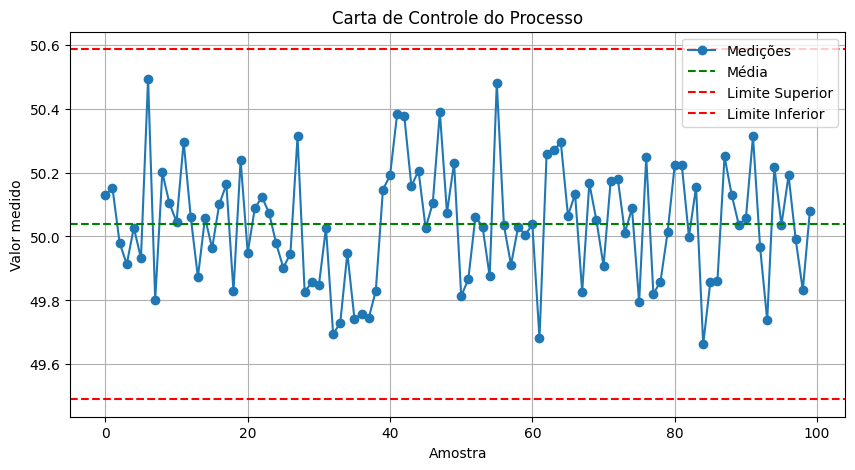

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# simulação de dados de processo
dados = np.random.normal(loc=50.0, scale=0.2, size=100)

# cálculo da média e do desvio padrão
media = np.mean(dados)
desvio = np.std(dados)

# cálculo dos limites de controle
limite_superior = media + 3 * desvio
limite_inferior = media - 3 * desvio

# criação da carta de controle
plt.figure(figsize=(10,5))
plt.plot(dados, marker='o', linestyle='-', label='Medições')
plt.axhline(media, color='green', linestyle='--', label='Média')
plt.axhline(limite_superior, color='red', linestyle='--', label='Limite Superior')
plt.axhline(limite_inferior, color='red', linestyle='--', label='Limite Inferior')

plt.title("Carta de Controle do Processo")
plt.xlabel("Amostra")
plt.ylabel("Valor medido")
plt.legend()
plt.grid()
plt.show()

## Cálculo de Cp e Cpk

In [23]:
import numpy as np

# simulação de dados de processo
dados = np.random.normal(loc=50.0, scale=0.2, size=100)

# limites de especificação
LSL = 49.5
USL = 50.5

# cálculo da média e do desvio padrão
media = np.mean(dados)
desvio = np.std(dados)

# cálculo dos índices
Cp = (USL - LSL) / (6 * desvio)

Cpk_superior = (USL - media) / (3 * desvio)
Cpk_inferior = (media - LSL) / (3 * desvio)

Cpk = min(Cpk_superior, Cpk_inferior)

print("Média do processo:", round(media,4))
print("Desvio padrão:", round(desvio,4))
print("Cp:", round(Cp,4))
print("Cpk:", round(Cpk,4))


Média do processo: 50.0079
Desvio padrão: 0.2231
Cp: 0.7472
Cpk: 0.7354


# Cálculo de Correlação entre Variáveis

In [31]:
import numpy as np

# simulação de dados de temperatura do processo
temperatura = np.random.normal(loc=200, scale=5, size=100)

# simulação de indicador de qualidade dependente da temperatura
qualidade = 0.05 * temperatura + np.random.normal(loc=0, scale=0.2, size=100)

# cálculo do coeficiente de correlação
correlacao = np.corrcoef(temperatura, qualidade)[0,1]

print("Coeficiente de correlação:", round(correlacao, 4))

Coeficiente de correlação: 0.7922


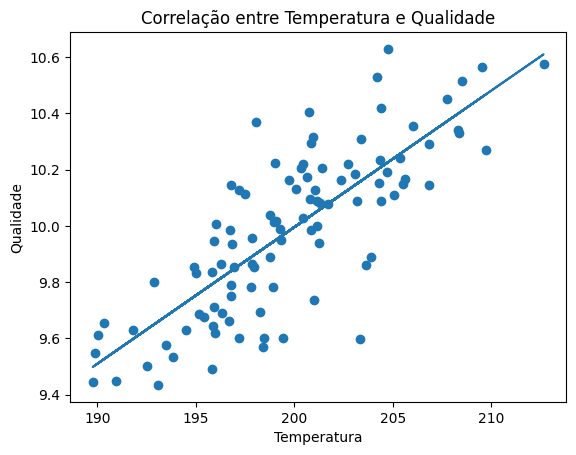

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

plt.scatter(temperatura, qualidade)
plt.xlabel("Temperatura")
plt.ylabel("Qualidade")
plt.title("Correlação entre Temperatura e Qualidade")
# linha de regressão
m, b = np.polyfit(temperatura, qualidade, 1)
plt.plot(temperatura, m*temperatura + b)
plt.show()

## Exemplo de modelo de Predição por Regressão Linear

In [34]:
import numpy as np
from sklearn.linear_model import LinearRegression

# simulação de dados de temperatura do processo
temperatura = np.random.normal(loc=200, scale=5, size=100)

# simulação de indicador de qualidade dependente da temperatura
qualidade = 0.05 * temperatura + np.random.normal(loc=0, scale=0.2, size=100)

# reorganização dos dados para o formato esperado pelo modelo
X = temperatura.reshape(-1, 1)
y = qualidade

# criação do modelo de regressão linear
modelo = LinearRegression()

# treinamento do modelo
modelo.fit(X, y)

# realização de previsões
predicoes = modelo.predict(X)

print("Coeficiente angular:", modelo.coef_[0])
print("Intercepto:", modelo.intercept_)

Coeficiente angular: 0.050264531712024635
Intercepto: -0.06752172239531262


## Exemplo de Detecção de Anomalias utilizando Isolation Forest

In [35]:
import numpy as np
from sklearn.ensemble import IsolationForest

# simulação de dados normais de processo
np.random.seed(42)
temperatura = np.random.normal(loc=200, scale=5, size=100)

# inserção de anomalias artificiais
temperatura[95:] = temperatura[95:] + 25

# reorganização dos dados
X = temperatura.reshape(-1, 1)

# criação e treinamento do modelo
modelo = IsolationForest(contamination=0.05, random_state=42)
modelo.fit(X)

# identificação de anomalias
anomalias = modelo.predict(X)

# -1 indica anomalia, +1 indica comportamento normal
print("Resultado da detecção:", anomalias)

Resultado da detecção: [ 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1
 -1  1 -1 -1]


## Modelo de Predição de defeitos por Regressão Linear

In [36]:
import numpy as np
from sklearn.linear_model import LinearRegression

# simulação de dados de processo
temperatura = np.random.uniform(180, 220, 200)

# simulação de taxa de defeitos associada à temperatura
defeitos = 0.02*(temperatura - 200)**2 + np.random.normal(0, 0.5, 200)

# ajuste do modelo
X = temperatura.reshape(-1,1)
y = defeitos

modelo = LinearRegression()
modelo.fit(X, y)

# previsão
pred = modelo.predict(X)

print("Coeficiente do modelo:", modelo.coef_[0])

Coeficiente do modelo: 0.0014371864252118978


# Aula 4 - Visualização de Dados

## Simulação de dados provenientes de sensores

In [37]:
import pandas as pd

# dados provenientes de sensores
dados_sensor = pd.DataFrame({
    'timestamp': pd.date_range('2025-01-01', periods=5, freq='min'),
    'temperatura': [100, 101, 102, 103, 104]
})

# dados provenientes do sistema de produção
dados_producao = pd.DataFrame({
    'timestamp': pd.date_range('2025-01-01', periods=5, freq='min'),
    'producao': [10, 11, 10, 12, 11]
})

# integração dos dados com base no tempo
dados_integrados = pd.merge(dados_sensor, dados_producao, on='timestamp')

print(dados_integrados)

            timestamp  temperatura  producao
0 2025-01-01 00:00:00          100        10
1 2025-01-01 00:01:00          101        11
2 2025-01-01 00:02:00          102        10
3 2025-01-01 00:03:00          103        12
4 2025-01-01 00:04:00          104        11


## Armazenamento de dados em um historiador

In [38]:
import sqlite3
import pandas as pd

# criação de dados simulados
dados = pd.DataFrame({
    'timestamp': pd.date_range('2025-01-01', periods=10, freq='min'),
    'temperatura': [70,71,72,73,74,75,76,77,78,79]
})

# conexão com banco de dados
conn = sqlite3.connect('historian.db')

# armazenamento dos dados
dados.to_sql('dados_temperatura', conn, if_exists='replace', index=False)

print("Dados armazenados no historiador.")

Dados armazenados no historiador.


## Recuperação dos dados do historiador

In [39]:
import pandas as pd

# Recuperação dos dados do banco SQLite
dados_recuperados = pd.read_sql_query("SELECT * FROM dados_temperatura", conn)

print("Dados recuperados do historiador:")
print(dados_recuperados)

Dados recuperados do historiador:
             timestamp  temperatura
0  2025-01-01 00:00:00           70
1  2025-01-01 00:01:00           71
2  2025-01-01 00:02:00           72
3  2025-01-01 00:03:00           73
4  2025-01-01 00:04:00           74
5  2025-01-01 00:05:00           75
6  2025-01-01 00:06:00           76
7  2025-01-01 00:07:00           77
8  2025-01-01 00:08:00           78
9  2025-01-01 00:09:00           79


## Dados com Tags

In [40]:
import pandas as pd

dados_tags = pd.DataFrame({
    'tag': ['Motor1.Temperatura', 'Motor1.Vibracao', 'Motor2.Temperatura'],
    'valor': [75.2, 0.03, 80.1],
    'timestamp': pd.date_range('2025-01-01', periods=3, freq='min')
})

print(dados_tags)

                  tag  valor           timestamp
0  Motor1.Temperatura  75.20 2025-01-01 00:00:00
1     Motor1.Vibracao   0.03 2025-01-01 00:01:00
2  Motor2.Temperatura  80.10 2025-01-01 00:02:00


## Estrutura do ambiente

In [41]:
estrutura = {
    "Planta": "Planta_A",
    "Linha": "Linha_1",
    "Equipamento": "Motor_3",
    "Sensor": "Temperatura"
}

print(estrutura)

{'Planta': 'Planta_A', 'Linha': 'Linha_1', 'Equipamento': 'Motor_3', 'Sensor': 'Temperatura'}


## Dados com contexto

In [42]:
dados_contextualizados = pd.DataFrame({
    'timestamp': pd.date_range('2025-01-01', periods=3, freq='min'),
    'temperatura': [75, 76, 77],
    'linha': ['Linha_1', 'Linha_1', 'Linha_1'],
    'produto': ['Produto_A', 'Produto_A', 'Produto_B']
})

print(dados_contextualizados)

            timestamp  temperatura    linha    produto
0 2025-01-01 00:00:00           75  Linha_1  Produto_A
1 2025-01-01 00:01:00           76  Linha_1  Produto_A
2 2025-01-01 00:02:00           77  Linha_1  Produto_B


## Simulação de RBAC

In [43]:
usuarios = {
    "operador": ["visualizar_dados"],
    "engenheiro": ["visualizar_dados", "analisar_dados"],
    "administrador": ["visualizar_dados", "analisar_dados", "modificar_dados"]
}

def verifica_permissao(usuario, acao):
    if acao in usuarios.get(usuario, []):
        return f"Usuário {usuario}: Permissão concedida"
    else:
        return f"Usuário {usuario}: Permissão negada"

usuario = "operador"
print(verifica_permissao(usuario, "modificar_dados"))

usuario = "administrador"
print(verifica_permissao(usuario, "modificar_dados"))

Usuário operador: Permissão negada
Usuário administrador: Permissão concedida


## Simulação de dados com rastreabilidade

In [44]:
import pandas as pd

dados = pd.DataFrame({
    "timestamp": pd.date_range("2025-01-01", periods=3, freq="min"),
    "temperatura": [75, 76, 77],
    "sensor": ["Sensor_A", "Sensor_A", "Sensor_A"],
    "origem": ["PLC_1", "PLC_1", "PLC_1"]
})

print(dados)

            timestamp  temperatura    sensor origem
0 2025-01-01 00:00:00           75  Sensor_A  PLC_1
1 2025-01-01 00:01:00           76  Sensor_A  PLC_1
2 2025-01-01 00:02:00           77  Sensor_A  PLC_1


## Simulação de consumo de API

In [45]:
import requests

# dados simulados criados em mockapi.io para
# exemplificar a integração com uma API industrial.

response = requests.get("https://699a5633377ac05ce28db830.mockapi.io/api/v1/status")
dados = response.json()
print(dados)
print(f"Vibração: {dados[0]['vibracao_rms']}")

[{'id': 1, 'temperatura': 25.3, 'vibracao_rms': 0.023, 'pressao': 5.2, 'bomba_status': True, 'timestamp': '2025-02-21T22:00:00Z'}]
Vibração: 0.023


## Envio de dados via MQTT

In [46]:
import paho.mqtt.client as mqtt

# criação do cliente MQTT
client = mqtt.Client(mqtt.CallbackAPIVersion.VERSION2)

# conexão com o broker
client.connect("broker.hivemq.com", 1883, 60)

# publicação de dados
client.publish("industria/sensor/temperatura", "75")

print("Dados enviados via MQTT")

Dados enviados via MQTT


## Dashboard de Análise de Temperatura

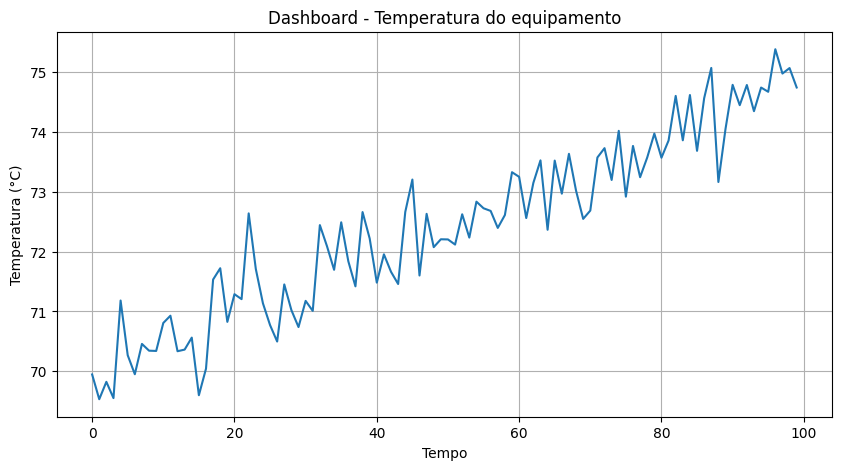

In [47]:
import numpy as np
import matplotlib.pyplot as plt

# simulação de dados
tempo = np.arange(0, 100)
temperatura = 70 + 0.05 * tempo + np.random.normal(0, 0.5, len(tempo))

plt.figure(figsize=(10,5))
plt.plot(tempo, temperatura)
plt.title("Dashboard - Temperatura do equipamento")
plt.xlabel("Tempo")
plt.ylabel("Temperatura (°C)")
plt.grid(True)
plt.show()

## Dashboard com destaque para limites operacionais

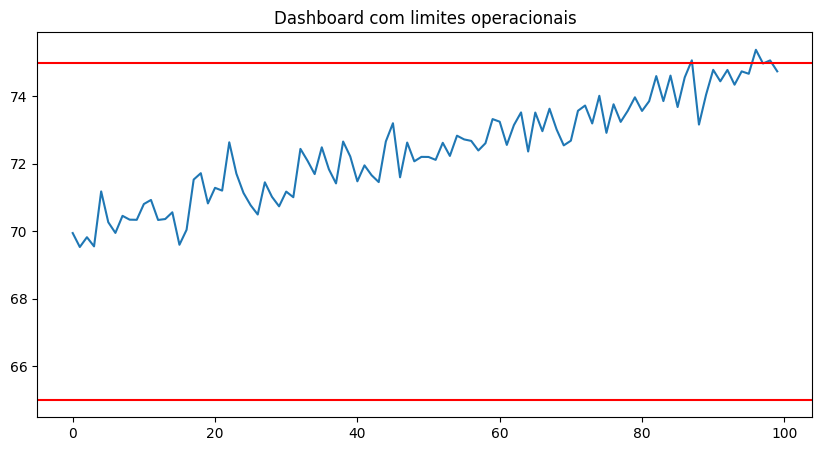

In [48]:
limite_superior = 75
limite_inferior = 65

plt.figure(figsize=(10,5))
plt.plot(temperatura)
plt.axhline(limite_superior, color='red')
plt.axhline(limite_inferior, color='red')
plt.title("Dashboard com limites operacionais")
plt.show()

## Dashboard com previsão

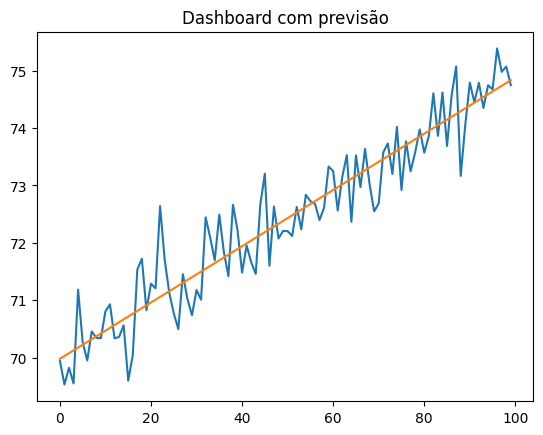

In [49]:
from sklearn.linear_model import LinearRegression

tempo = tempo.reshape(-1,1)

modelo = LinearRegression()
modelo.fit(tempo, temperatura)

previsao = modelo.predict(tempo)

plt.plot(tempo, temperatura)
plt.plot(tempo, previsao)
plt.title("Dashboard com previsão")
plt.show()

## Dashboard interativo para monitoramento de temperatura

In [50]:
import numpy as np
import plotly.graph_objects as go

# simulação de dados industriais
tempo = np.arange(0, 100)
temperatura = 70 + 0.1 * tempo + np.random.normal(0, 0.5, len(tempo))

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=tempo,
    y=temperatura,
    mode='lines',
    name='Temperatura'
))

fig.update_layout(
    title="Dashboard Industrial - Monitoramento de Temperatura",
    xaxis_title="Tempo",
    yaxis_title="Temperatura (°C)"
)

fig.show()